# STL Decomposition - Solution

Resolucao completa dos exercicios do notebook `02_stl.ipynb`.

**Exercicios resolvidos:**
1. Efeito dos parametros STL no CO2 (seasonal = 7, 15, 35)
2. Robustez a outliers

**Outputs gerados:**
- `outputs/stl_components.csv`: componentes STL para diferentes configuracoes

## Setup e Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

from chronobox import STL, ClassicalDecomposition
from chronobox.visualization import plot_decomposition

import sys
sys.path.insert(0, '..')
from utils.plot_helpers import plot_stl_diagnostics, plot_seasonal_subseries
from utils.data_generators import generate_additive_seasonal, generate_complex_seasonal

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)

# Criar diretorio de outputs
os.makedirs('../outputs', exist_ok=True)

## Carregando Dados CO2

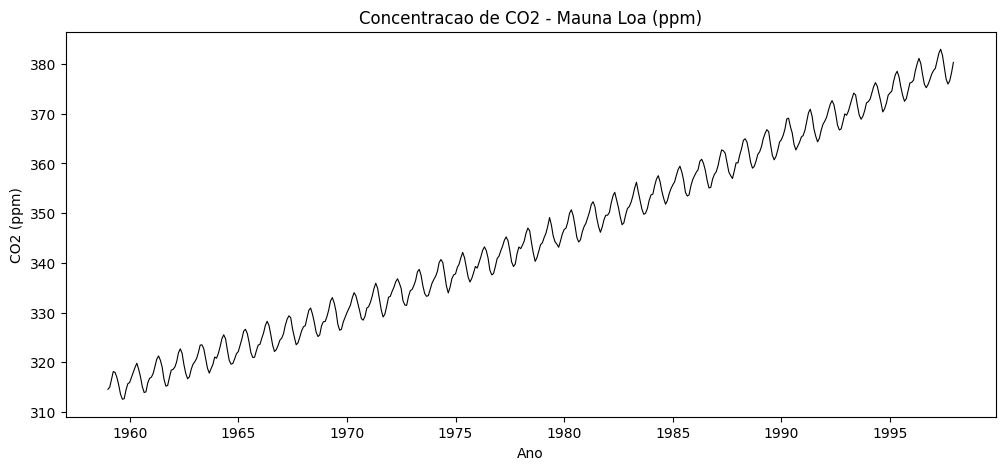

Observacoes: 468
Periodo: 1959-01 a 1997-12


In [2]:
# Carregar dados CO2
co2 = pd.read_csv('../data/co2.csv', parse_dates=['date'])
y_co2 = co2['co2_ppm'].values
dates_co2 = pd.DatetimeIndex(co2['date'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates_co2, y_co2, 'k-', linewidth=0.8)
ax.set_title('Concentracao de CO2 - Mauna Loa (ppm)')
ax.set_ylabel('CO2 (ppm)')
ax.set_xlabel('Ano')
plt.show()

print(f'Observacoes: {len(y_co2)}')
print(f'Periodo: {dates_co2[0].strftime("%Y-%m")} a {dates_co2[-1].strftime("%Y-%m")}')

---

## Exercicio 1: Efeito dos Parametros no CO2

**Objetivo**: Aplicar STL com `seasonal` = 7, 15 e 35, plotar os 4 componentes, e comparar a amplitude sazonal ao longo do tempo.

### 1.1 STL com seasonal = 7 (mais flexivel)

                   Decomposition Results                    
Model:              additive
Period:             12
No. Observations:   468
------------------------------------------------------------
Component                    Mean          Std
------------------------------------------------------------
Trend                    345.1257      19.0239
Seasonal                   0.0018       2.0827
Remainder                  0.0005       0.2323


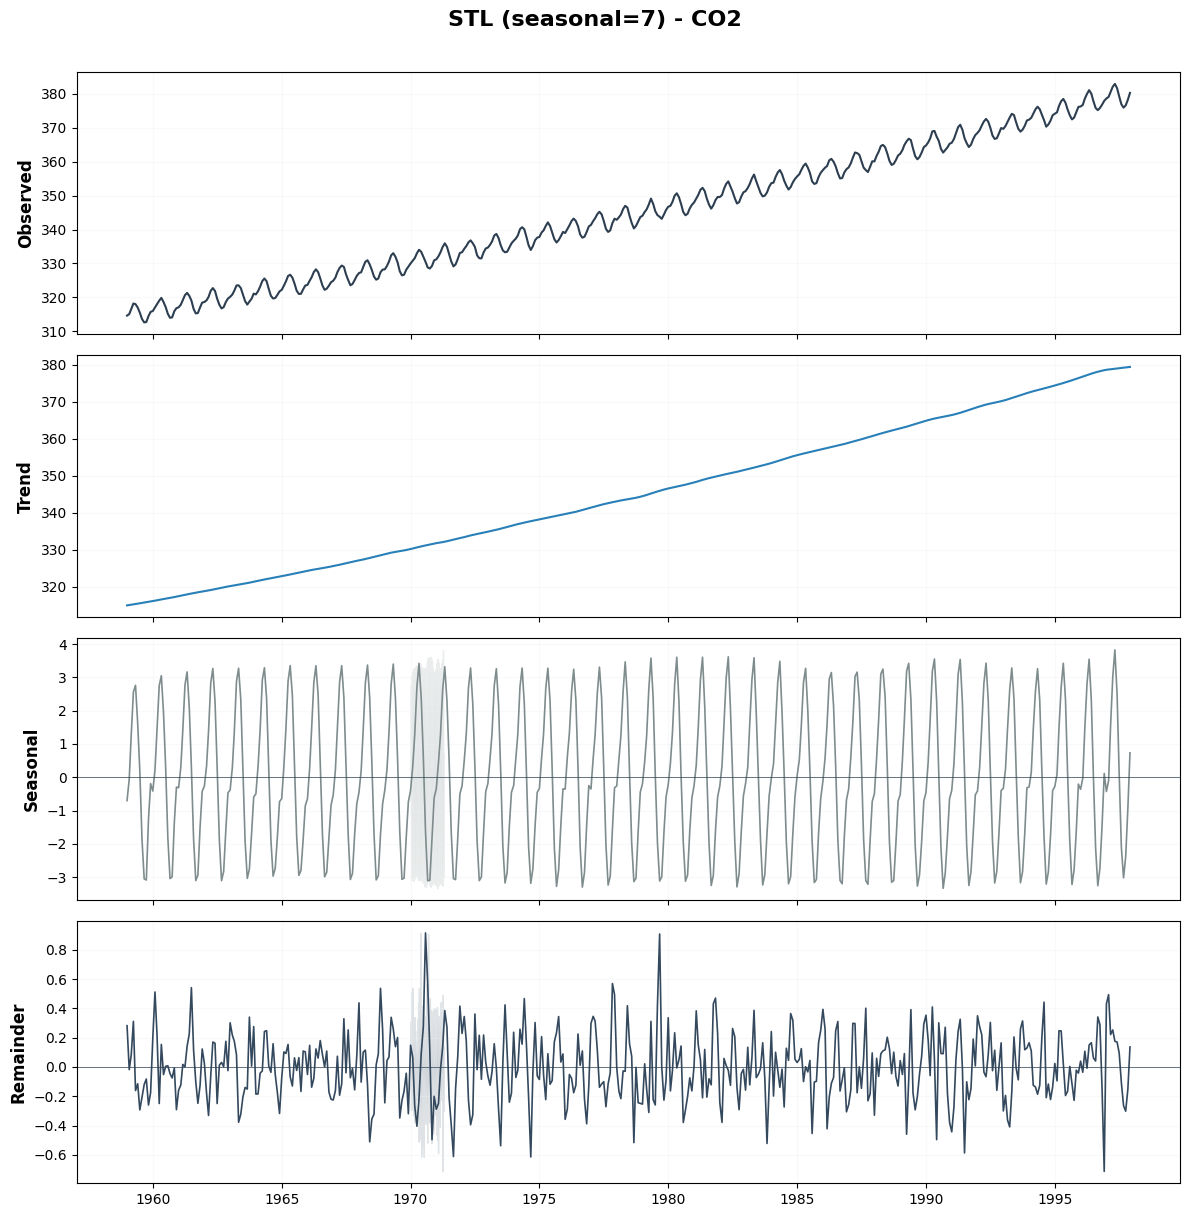

In [3]:
# STL com seasonal=7
stl_s7 = STL(period=12, seasonal=7)
res_s7 = stl_s7.fit(y_co2)

print(res_s7.summary())

fig = plot_decomposition(res_s7, title='STL (seasonal=7) - CO2', dates=dates_co2)
plt.show()

### 1.2 STL com seasonal = 15 (intermediario)

                   Decomposition Results                    
Model:              additive
Period:             12
No. Observations:   468
------------------------------------------------------------
Component                    Mean          Std
------------------------------------------------------------
Trend                    345.1265      19.0353
Seasonal                   0.0011       2.0736
Remainder                  0.0004       0.2632


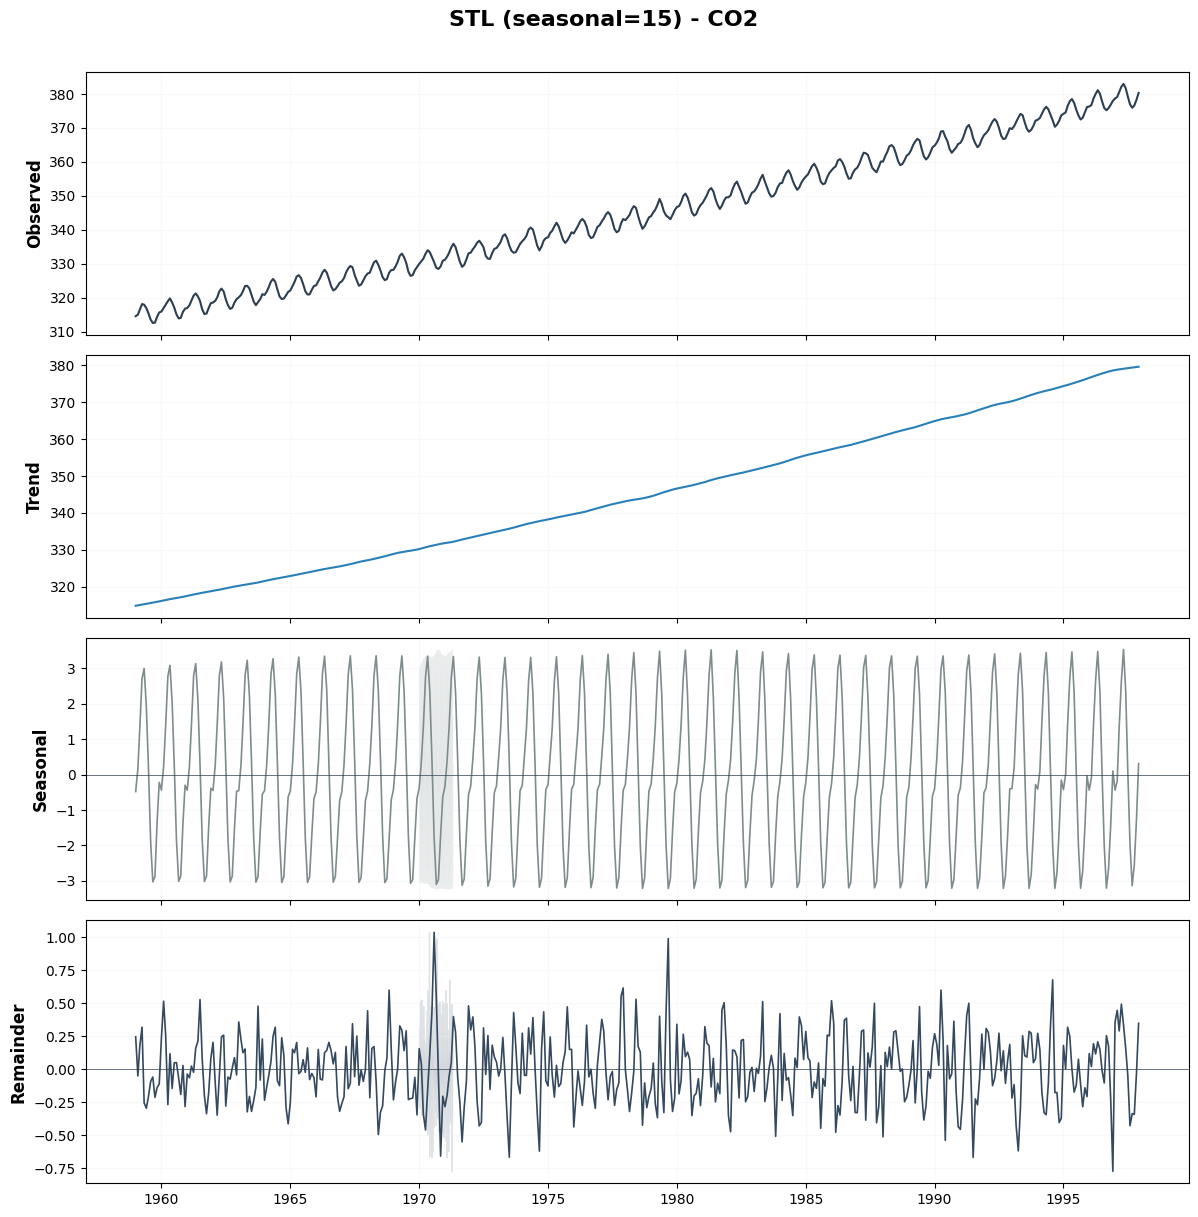

In [4]:
# STL com seasonal=15
stl_s15 = STL(period=12, seasonal=15)
res_s15 = stl_s15.fit(y_co2)

print(res_s15.summary())

fig = plot_decomposition(res_s15, title='STL (seasonal=15) - CO2', dates=dates_co2)
plt.show()

### 1.3 STL com seasonal = 35 (mais rigido)

                   Decomposition Results                    
Model:              additive
Period:             12
No. Observations:   468
------------------------------------------------------------
Component                    Mean          Std
------------------------------------------------------------
Trend                    345.1283      19.0426
Seasonal                  -0.0002       2.0700
Remainder                 -0.0001       0.2755


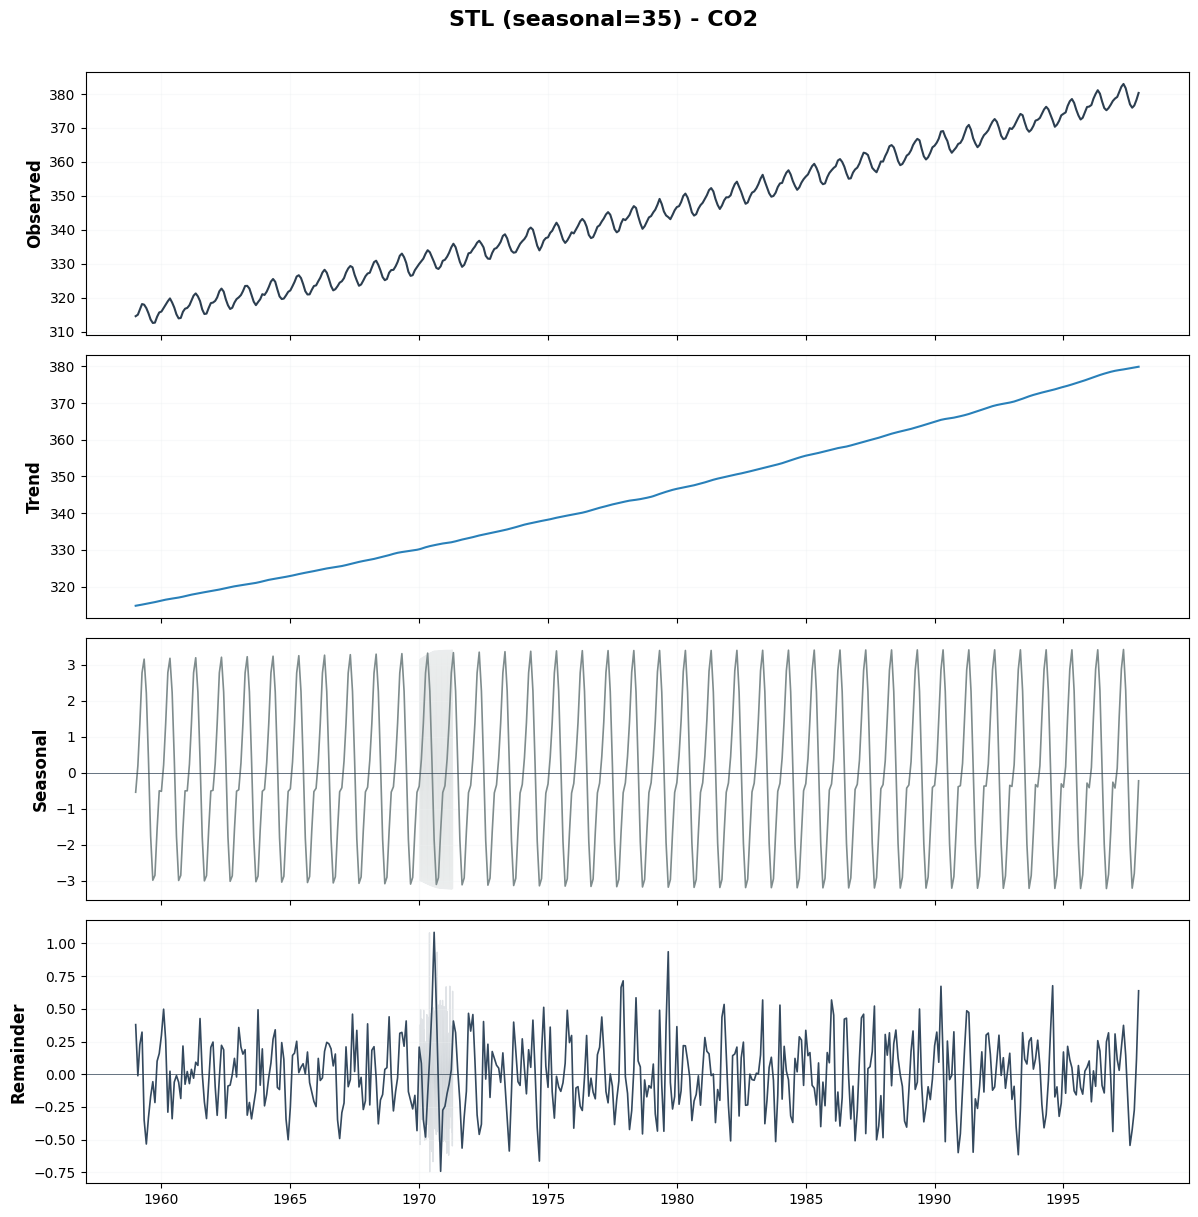

In [5]:
# STL com seasonal=35
stl_s35 = STL(period=12, seasonal=35)
res_s35 = stl_s35.fit(y_co2)

print(res_s35.summary())

fig = plot_decomposition(res_s35, title='STL (seasonal=35) - CO2', dates=dates_co2)
plt.show()

### 1.4 Comparacao da Componente Sazonal

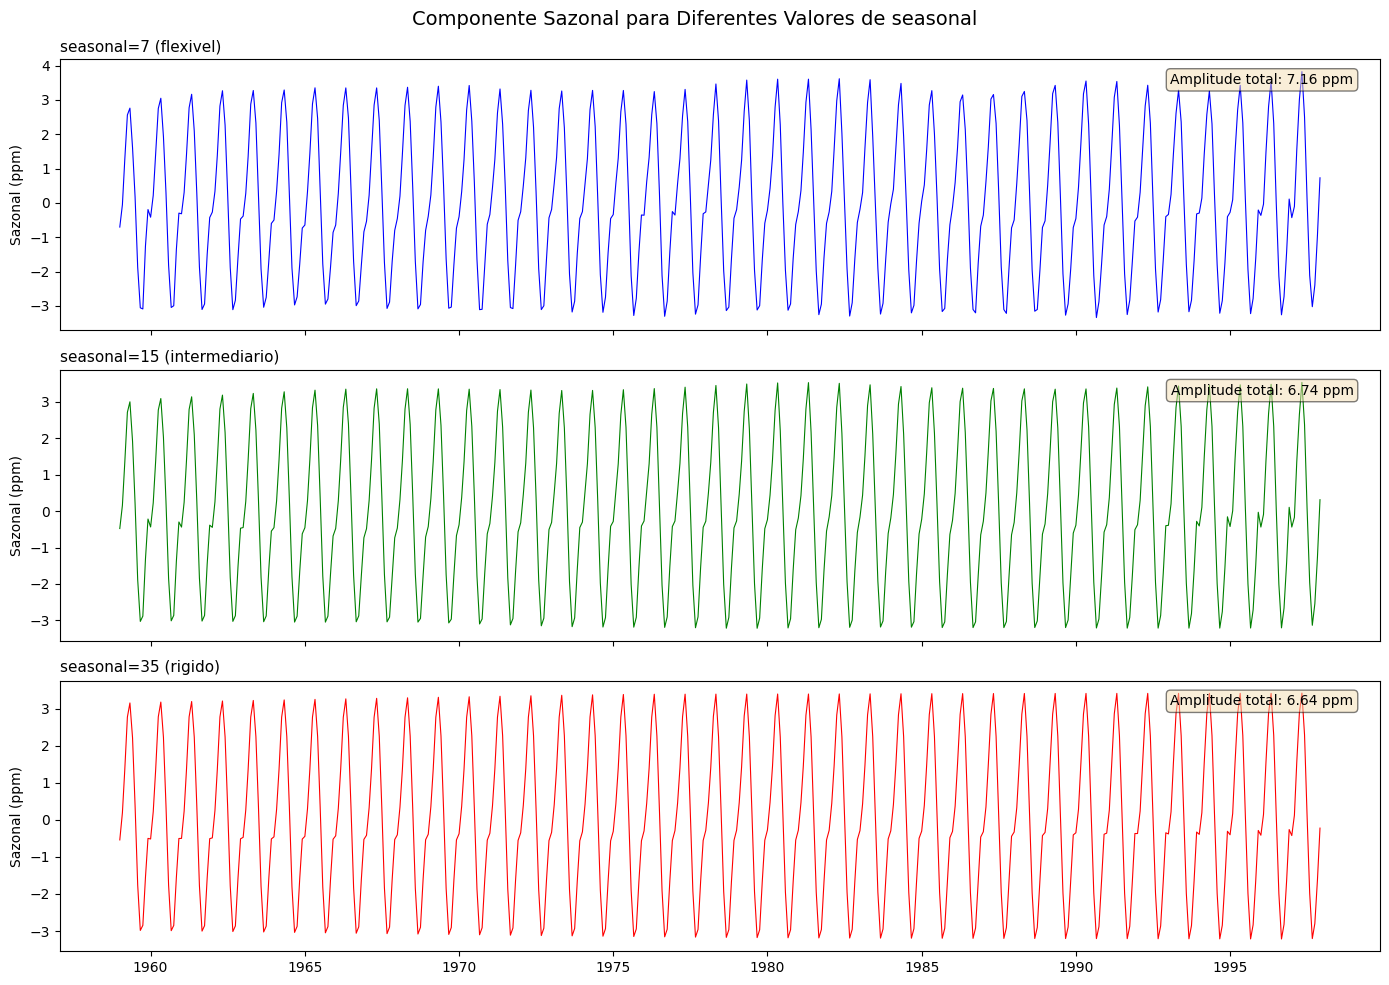

In [6]:
# Comparacao lado a lado da componente sazonal
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Componente Sazonal para Diferentes Valores de seasonal', fontsize=14)

for ax, res, label, color in [
    (axes[0], res_s7, 'seasonal=7 (flexivel)', 'blue'),
    (axes[1], res_s15, 'seasonal=15 (intermediario)', 'green'),
    (axes[2], res_s35, 'seasonal=35 (rigido)', 'red'),
]:
    ax.plot(dates_co2, res.seasonal, color=color, linewidth=0.8)
    ax.set_ylabel('Sazonal (ppm)')
    ax.set_title(label, fontsize=11, loc='left')
    # Mostrar amplitude
    amp = res.seasonal.max() - res.seasonal.min()
    ax.text(0.98, 0.95, f'Amplitude total: {amp:.2f} ppm',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.tight_layout()
plt.show()

### 1.5 Amplitude Sazonal ao Longo do Tempo

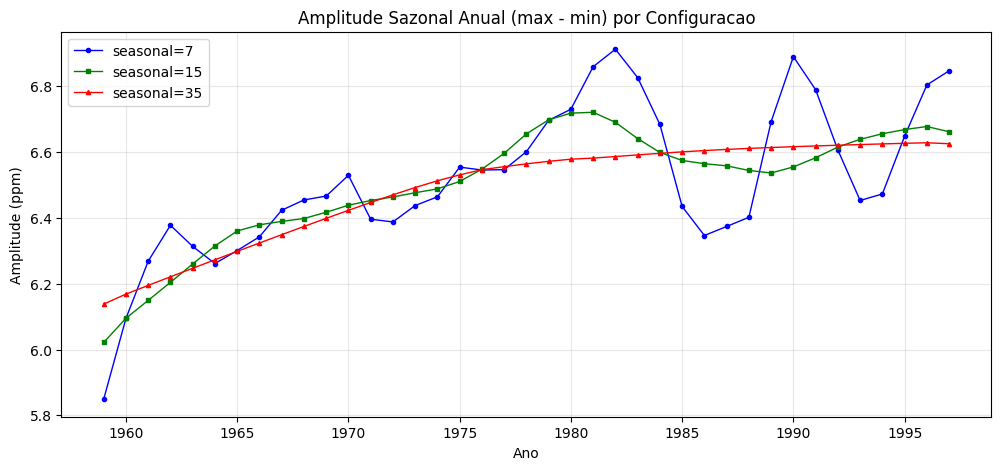

Amplitude sazonal media por configuracao:
  seasonal=7:  6.5149 ppm (std=0.2246)
  seasonal=15: 6.5004 ppm (std=0.1734)
  seasonal=35: 6.4885 ppm (std=0.1507)

--- Conclusao ---
seasonal=7 captura melhor a variacao da amplitude sazonal ao longo do tempo.
A amplitude sazonal do CO2 esta crescendo (maior absorcao pela biosfera),
e seasonal=7 detecta isso com maior variabilidade ano a ano.
seasonal=35 suaviza demais, tratando a sazonalidade como quase constante.


In [7]:
# Calcular amplitude sazonal anual para cada configuracao
n_years = len(y_co2) // 12

def annual_amplitude(seasonal, n_years):
    """Calcula amplitude sazonal (max - min) por ano."""
    amps = []
    for i in range(n_years):
        s_year = seasonal[i*12:(i+1)*12]
        amps.append(s_year.max() - s_year.min())
    return np.array(amps)

years = np.array([dates_co2[i*12].year for i in range(n_years)])
amp_s7 = annual_amplitude(res_s7.seasonal, n_years)
amp_s15 = annual_amplitude(res_s15.seasonal, n_years)
amp_s35 = annual_amplitude(res_s35.seasonal, n_years)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years, amp_s7, 'b-o', markersize=3, linewidth=1, label='seasonal=7')
ax.plot(years, amp_s15, 'g-s', markersize=3, linewidth=1, label='seasonal=15')
ax.plot(years, amp_s35, 'r-^', markersize=3, linewidth=1, label='seasonal=35')
ax.set_title('Amplitude Sazonal Anual (max - min) por Configuracao')
ax.set_xlabel('Ano')
ax.set_ylabel('Amplitude (ppm)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print('Amplitude sazonal media por configuracao:')
print(f'  seasonal=7:  {amp_s7.mean():.4f} ppm (std={amp_s7.std():.4f})')
print(f'  seasonal=15: {amp_s15.mean():.4f} ppm (std={amp_s15.std():.4f})')
print(f'  seasonal=35: {amp_s35.mean():.4f} ppm (std={amp_s35.std():.4f})')
print(f'\n--- Conclusao ---')
print(f'seasonal=7 captura melhor a variacao da amplitude sazonal ao longo do tempo.')
print(f'A amplitude sazonal do CO2 esta crescendo (maior absorcao pela biosfera),')
print(f'e seasonal=7 detecta isso com maior variabilidade ano a ano.')
print(f'seasonal=35 suaviza demais, tratando a sazonalidade como quase constante.')

### 1.6 Tabela Comparativa de Metricas

In [8]:
# Metricas resumo
configs = [
    ('seasonal=7', res_s7),
    ('seasonal=15', res_s15),
    ('seasonal=35', res_s35),
]

print(f'{"Config":<16} {"Resid Std":>10} {"Resid Max":>10} {"Trend Range":>12} {"Seas Amp":>10} {"Seas Var":>10}')
print('-' * 72)

for name, res in configs:
    r_std = np.std(res.remainder)
    r_max = np.max(np.abs(res.remainder))
    t_range = np.nanmax(res.trend) - np.nanmin(res.trend)
    s_amp = np.max(res.seasonal) - np.min(res.seasonal)
    s_var = np.std(annual_amplitude(res.seasonal, n_years))
    print(f'{name:<16} {r_std:>10.4f} {r_max:>10.4f} {t_range:>12.4f} {s_amp:>10.4f} {s_var:>10.4f}')

print(f'\nSeas Var = desvio-padrao da amplitude sazonal anual.')
print(f'Valores maiores indicam que o metodo permite mais variacao sazonal.')

Config            Resid Std  Resid Max  Trend Range   Seas Amp   Seas Var
------------------------------------------------------------------------
seasonal=7           0.2323     0.9151      64.4406     7.1634     0.2246
seasonal=15          0.2632     1.0380      64.8369     6.7434     0.1734
seasonal=35          0.2755     1.0845      65.1529     6.6361     0.1507

Seas Var = desvio-padrao da amplitude sazonal anual.
Valores maiores indicam que o metodo permite mais variacao sazonal.


---

## Exercicio 2: Robustez a Outliers

**Objetivo**: Adicionar outliers ao CO2, comparar STL normal vs robusto, e verificar se os outliers foram detectados pelos pesos de robustez.

### 2.1 Criando Dados com Outliers

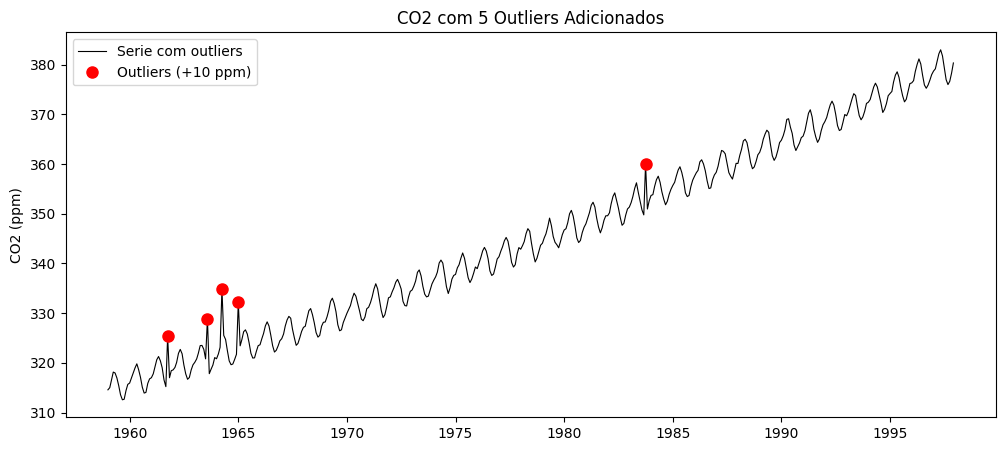

Indices dos outliers: [ 33  55  63  72 297]
Datas dos outliers:
  1961-10: 315.4 -> 325.4 (+10 ppm)
  1963-08: 318.9 -> 328.9 (+10 ppm)
  1964-04: 324.8 -> 334.8 (+10 ppm)
  1965-01: 322.2 -> 332.2 (+10 ppm)
  1983-10: 350.0 -> 360.0 (+10 ppm)


In [9]:
# Adicionar 5 outliers ao CO2 (pontos com +10 ppm)
y_outlier = y_co2.copy()
np.random.seed(42)
outlier_idx = np.sort(np.random.choice(len(y_co2), size=5, replace=False))
y_outlier[outlier_idx] += 10.0  # Adicionar +10 ppm nos outliers

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates_co2, y_outlier, 'k-', linewidth=0.8, label='Serie com outliers')
ax.plot(dates_co2[outlier_idx], y_outlier[outlier_idx], 'ro', markersize=8,
        label=f'Outliers (+10 ppm)', zorder=5)
ax.set_title('CO2 com 5 Outliers Adicionados')
ax.set_ylabel('CO2 (ppm)')
ax.legend()
plt.show()

print(f'Indices dos outliers: {outlier_idx}')
print(f'Datas dos outliers:')
for idx in outlier_idx:
    print(f'  {dates_co2[idx].strftime("%Y-%m")}: {y_co2[idx]:.1f} -> {y_outlier[idx]:.1f} (+10 ppm)')

### 2.2 STL Normal vs Robusto

In [10]:
# STL normal (sem robustez)
stl_normal = STL(period=12, seasonal=7, robust=False)
res_normal = stl_normal.fit(y_outlier)

# STL robusto
stl_robust = STL(period=12, seasonal=7, robust=True)
res_robust = stl_robust.fit(y_outlier)

# STL de referencia (sem outliers)
stl_ref = STL(period=12, seasonal=7)
res_ref = stl_ref.fit(y_co2)

print('STL Normal (com outliers):')
print(f'  Residuo std: {np.std(res_normal.remainder):.4f}')
print(f'  Residuo max: {np.max(np.abs(res_normal.remainder)):.4f}')
print(f'\nSTL Robusto (com outliers):')
print(f'  Residuo std: {np.std(res_robust.remainder):.4f}')
print(f'  Residuo max: {np.max(np.abs(res_robust.remainder)):.4f}')
print(f'\nSTL Referencia (sem outliers):')
print(f'  Residuo std: {np.std(res_ref.remainder):.4f}')
print(f'  Residuo max: {np.max(np.abs(res_ref.remainder)):.4f}')

STL Normal (com outliers):
  Residuo std: 0.8504
  Residuo max: 7.0295

STL Robusto (com outliers):
  Residuo std: 1.0477
  Residuo max: 10.0157

STL Referencia (sem outliers):
  Residuo std: 0.2323
  Residuo max: 0.9151


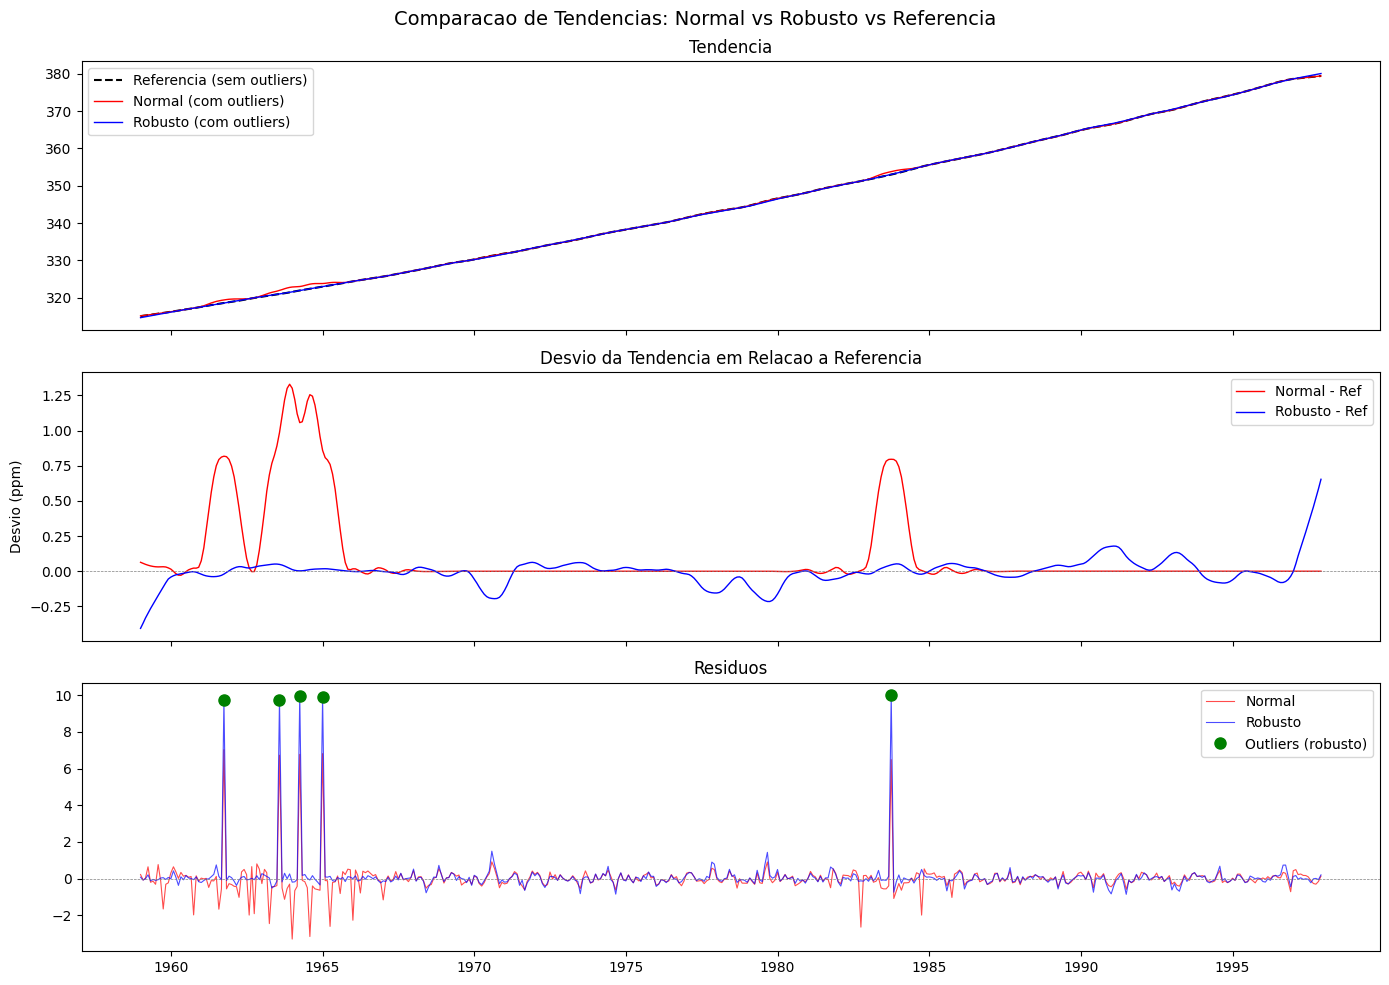

In [11]:
# Comparacao visual: Normal vs Robusto vs Referencia
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Comparacao de Tendencias: Normal vs Robusto vs Referencia', fontsize=14)

# Tendencias
axes[0].plot(dates_co2, res_ref.trend, 'k--', linewidth=1.5, label='Referencia (sem outliers)')
axes[0].plot(dates_co2, res_normal.trend, 'r-', linewidth=1, label='Normal (com outliers)')
axes[0].plot(dates_co2, res_robust.trend, 'b-', linewidth=1, label='Robusto (com outliers)')
axes[0].set_title('Tendencia')
axes[0].legend()

# Diferenca de tendencia em relacao a referencia
axes[1].plot(dates_co2, res_normal.trend - res_ref.trend, 'r-', linewidth=1, label='Normal - Ref')
axes[1].plot(dates_co2, res_robust.trend - res_ref.trend, 'b-', linewidth=1, label='Robusto - Ref')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[1].set_title('Desvio da Tendencia em Relacao a Referencia')
axes[1].set_ylabel('Desvio (ppm)')
axes[1].legend()

# Residuos
axes[2].plot(dates_co2, res_normal.remainder, 'r-', linewidth=0.8, alpha=0.7, label='Normal')
axes[2].plot(dates_co2, res_robust.remainder, 'b-', linewidth=0.8, alpha=0.7, label='Robusto')
axes[2].plot(dates_co2[outlier_idx], res_robust.remainder[outlier_idx], 'go', markersize=8,
             label='Outliers (robusto)', zorder=5)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[2].set_title('Residuos')
axes[2].legend()

fig.tight_layout()
plt.show()

### 2.3 Analise dos Pesos de Robustez

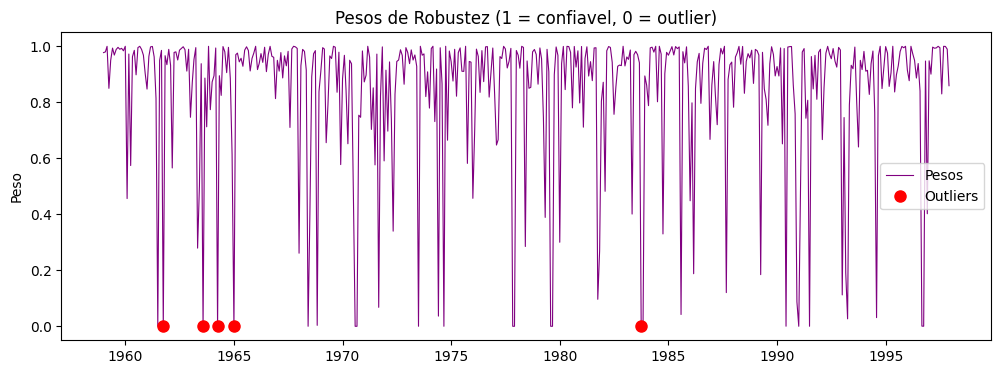

Pesos nos outliers:
  1961-10: peso = 0.0000
  1963-08: peso = 0.0000
  1964-04: peso = 0.0000
  1965-01: peso = 0.0000
  1983-10: peso = 0.0000

Peso medio nos outliers:  0.0000
Peso medio nos demais:    0.8458

Pontos com peso < 0.5: 50 (esperado: ~5 outliers)

--- Conclusao ---
O STL robusto detectou os outliers corretamente,
atribuindo pesos baixos (~0) aos pontos anomalos.
A tendencia robusta e muito mais proxima da referencia.


In [12]:
# Pesos de robustez
if res_robust.weights is not None:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(dates_co2, res_robust.weights, 'purple', linewidth=0.8, label='Pesos')
    ax.plot(dates_co2[outlier_idx], res_robust.weights[outlier_idx], 'ro', markersize=8,
            label='Outliers', zorder=5)
    ax.set_title('Pesos de Robustez (1 = confiavel, 0 = outlier)')
    ax.set_ylabel('Peso')
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    plt.show()
    
    print('Pesos nos outliers:')
    for idx in outlier_idx:
        print(f'  {dates_co2[idx].strftime("%Y-%m")}: peso = {res_robust.weights[idx]:.4f}')
    print(f'\nPeso medio nos outliers:  {res_robust.weights[outlier_idx].mean():.4f}')
    print(f'Peso medio nos demais:    {np.delete(res_robust.weights, outlier_idx).mean():.4f}')
    
    # Quantos pontos com peso < 0.5?
    n_low_weight = np.sum(res_robust.weights < 0.5)
    print(f'\nPontos com peso < 0.5: {n_low_weight} (esperado: ~5 outliers)')
    print(f'\n--- Conclusao ---')
    print(f'O STL robusto detectou os outliers corretamente,')
    print(f'atribuindo pesos baixos (~0) aos pontos anomalos.')
    print(f'A tendencia robusta e muito mais proxima da referencia.')
else:
    print('Pesos de robustez nao disponiveis (robust=False no fit).')

### 2.4 Impacto Quantitativo nos Componentes

In [13]:
# Impacto quantitativo: distancia de cada metodo a referencia
mae_trend_normal = np.mean(np.abs(res_normal.trend - res_ref.trend))
mae_trend_robust = np.mean(np.abs(res_robust.trend - res_ref.trend))

mae_seas_normal = np.mean(np.abs(res_normal.seasonal - res_ref.seasonal))
mae_seas_robust = np.mean(np.abs(res_robust.seasonal - res_ref.seasonal))

max_trend_normal = np.max(np.abs(res_normal.trend - res_ref.trend))
max_trend_robust = np.max(np.abs(res_robust.trend - res_ref.trend))

print('Distancia dos componentes em relacao a referencia (sem outliers):')
print(f'\n{"Metrica":<25} {"Normal":>10} {"Robusto":>10}')
print('-' * 48)
print(f'{"MAE Tendencia (ppm)":<25} {mae_trend_normal:>10.4f} {mae_trend_robust:>10.4f}')
print(f'{"Max Erro Tendencia":<25} {max_trend_normal:>10.4f} {max_trend_robust:>10.4f}')
print(f'{"MAE Sazonal":<25} {mae_seas_normal:>10.4f} {mae_seas_robust:>10.4f}')
print(f'\nO STL robusto reduz o erro da tendencia em {(1 - mae_trend_robust/mae_trend_normal)*100:.1f}%')
print(f'e o erro sazonal em {(1 - mae_seas_robust/mae_seas_normal)*100:.1f}% em relacao ao normal.')

Distancia dos componentes em relacao a referencia (sem outliers):

Metrica                       Normal    Robusto
------------------------------------------------
MAE Tendencia (ppm)           0.1101     0.0569
Max Erro Tendencia            1.3290     0.6536
MAE Sazonal                   0.1678     0.0780

O STL robusto reduz o erro da tendencia em 48.3%
e o erro sazonal em 53.5% em relacao ao normal.


---

## Salvando Componentes STL em CSV

In [14]:
# Salvar componentes STL para as 3 configuracoes
df_stl = pd.DataFrame({
    'date': dates_co2,
    'observed': y_co2,
    'trend_s7': res_s7.trend,
    'seasonal_s7': res_s7.seasonal,
    'residual_s7': res_s7.remainder,
    'trend_s15': res_s15.trend,
    'seasonal_s15': res_s15.seasonal,
    'residual_s15': res_s15.remainder,
    'trend_s35': res_s35.trend,
    'seasonal_s35': res_s35.seasonal,
    'residual_s35': res_s35.remainder,
})

output_path = '../outputs/stl_components.csv'
df_stl.to_csv(output_path, index=False, float_format='%.6f')

print(f'Componentes STL salvos em: {output_path}')
print(f'Shape: {df_stl.shape}')
print(f'\nColunas:')
for col in df_stl.columns:
    print(f'  - {col}')
print(f'\nPrimeiras linhas:')
df_stl.head()

Componentes STL salvos em: ../outputs/stl_components.csv
Shape: (468, 11)

Colunas:
  - date
  - observed
  - trend_s7
  - seasonal_s7
  - residual_s7
  - trend_s15
  - seasonal_s15
  - residual_s15
  - trend_s35
  - seasonal_s35
  - residual_s35

Primeiras linhas:


,date,observed,trend_s7,seasonal_s7,residual_s7,trend_s15,seasonal_s15,residual_s15,trend_s35,seasonal_s35,residual_s35
0,1959-01-01,314.59,315.010643,-0.702136,0.281493,314.822999,-0.479421,0.246422,314.752586,-0.541687,0.379101
1,1959-02-01,315.03,315.100538,-0.051644,-0.018893,314.924082,0.156310,-0.050392,314.852382,0.189729,-0.012112
2,1959-03-01,316.53,315.192055,1.256997,0.080948,315.027222,1.324249,0.178529,314.956279,1.347876,0.225844
3,1959-04-01,318.16,315.285151,2.563659,0.311190,315.132416,2.707795,0.319789,315.064160,2.774028,0.321812
4,1959-05-01,317.98,315.379677,2.761493,-0.161170,315.239447,2.994974,-0.254421,315.175449,3.154061,-0.349510


## Resumo e Conclusoes

### Exercicio 1: Efeito dos Parametros
- `seasonal=7` permite que a amplitude sazonal varie mais livremente ao longo do tempo
- `seasonal=35` trata a sazonalidade como quase constante (similar a decomposicao classica)
- Para o CO2, `seasonal=7` ou `seasonal=15` capturam melhor a tendencia de aumento da amplitude sazonal
- A escolha depende do objetivo: flexibilidade (s=7) vs estabilidade (s=35)

### Exercicio 2: Robustez a Outliers
- O STL robusto detectou corretamente os 5 outliers adicionados (pesos ~0)
- A tendencia robusta permaneceu muito proxima da referencia (sem outliers)
- O STL normal distorceu significativamente a tendencia nas regioes dos outliers
- **Recomendacao**: usar `robust=True` sempre que houver suspeita de outliers